<div style="font-weight: bold; color:#5D8AA8" align="center">
    <div style="font-size: xx-large">Métodos Funcionales en Aprendizaje Automático</div><br>
    <div style="font-size: x-large; color:gray">Homework 03 - Diffusion Maps</div><br>
    <div style="font-size: large">Authors</div><br>Sergio Fernández Munguía e Iñigo Martínez Ciriza</div><hr>
</div>

**Initial Configuration**

This cell defines the configuration of Jupyter Notebooks.

In [1]:
%%html
<style>
    .qst {background-color: #b1cee3; padding:10px; border-radius: 5px; border: solid 2px #5D8AA8;}
    .qst:before {font-weight: bold; content:"Exercise"; display: block; margin: 0px 10px 10px 10px;}
    h1, h2, h3 {color: #5D8AA8;}
    .text_cell_render p {text-align: justify; text-justify: inter-word;}
</style>

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

This cell imports the packages to be used.

In [3]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
from itertools import product
from sklearn.datasets import make_blobs, make_swiss_roll, make_s_curve
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.utils.extmath import svd_flip
from mpl_toolkits.mplot3d import Axes3D
Axes3D

matplotlib.rc('figure', figsize=(15, 5))

seed = 123
my_cmap = plt.cm.Spectral

# Introduction

This practical assignment is about implementing the manifold learning method **Diffusion Maps**, following the *scikit-learn* template for manifold learning algorithms.

We will design two main functions: one for training the algorithm, obtaining the affinity matrix and the embedded coordinates, and a second one for extending these coordinates for new patterns.

# Requirements

The objective of this assignment is to complete the class DM sketched below, which should contain at least the following methods.

`__init__(self, sigma, n_components, step=1, alpha=1)`

* This is the construction method for the class, with the following parameters:
    * `sigma`: Kernel parameter for the Gaussian kernel.
    * `n_components`: dimension of the embedding.
    * `step`: step in the Markov Chain.
    * `alpha`: density influence. It should take a value in `[0,1]`.
* This method just store the parameters in the fields of the class, to be used when needed.

`fit(self, X, y=None)`

* This is the training method, the one that performs the Diffusion Maps algorithm. 

* This method should store the affinity matrix and also the eigenvectors to computed the transformation.

`fit_transform(self, X, y=None)`

* This method returns the embedding coordinates for the training data.
* It should also store the affinity matrix and the coordinates needed to compute the transformation (for example over new, unseen patterns).

`transform(self, X)`

* This method will obtain approximated coordinates for new, unseen data points. 
* It uses for this purpose the Nyström Formula.

## Some recommendations

* It should allow to fix all the DM possibilities (different steps, density normalization...). To allow a change in the kernel function could be also a nice idea.
* Implement all the auxiliary functions that you may need, for example, for deciding the best parameter values in each case.
* It could be a nice idea to offer a deterministic output, that do not depend on the sign of the eigenvectors.

# Implementation

<div class="qst">

* Complete the `DM` class below, satisfying the described requirements.

</div>

In [32]:
from sklearn.base import BaseEstimator, TransformerMixin

class DM(TransformerMixin, BaseEstimator):
    """
        Diffusion Maps.
    """
    def __init__(self, sigma, n_components, alpha, step=1):
        # Assignment of the hyper-parameters
        self.sigma = sigma
        self.n_components = n_components
        self.step = step
        self.alpha = alpha

    def fit(self, X, y=None):
        """Compute the embedding vectors for data X
        Parameters
        ----------
        X : array-like of shape [n_samples, n_features]
            training set.
        y : Ignored
        Returns
        -------
        self : returns an instance of self.
        """
        self.X = X

        # Gaussian kernel
        pairwise_dists = pairwise_distances(X, X, squared=True)
        K = np.exp(-pairwise_dists / (2 * self.sigma**2))
        self.affinity_matrix = K
        
        # Degree of each node kernel (save them for tranform)
        D = np.sum(K, axis=1)**self.alpha
        
        # Normalized kernel
        K_alpha = K / D / D.T
        
        # Degree of each node of normalized kernel
        D_alpha = np.sum(K_alpha, axis=1).reshape(-1, 1)
        
        # Compute the probability matrix
        P = K_alpha / D_alpha

        # Compute the stationary distribution
        pi = (D / np.sum(D)).reshape(-1, 1)
        
        # Compute the A matrix
        D_sqrt = np.sqrt(D)
        A = K / np.outer(D_sqrt, D_sqrt)

        # SVD decomposition
        eigenvectors, eigenvalues, V = np.linalg.svd(A)
        
        # Flip the eigenvectors sign to ensure deterministic output from SVD
        eigenvectors, _ = svd_flip(eigenvectors, V)
        
        # Normalize eigenvectors
        eigenvectors = eigenvectors / np.sqrt(pi)
        
        # Save the eigenvalues and eigenvectors
        self.lambdas_ = eigenvalues[1:self.n_components + 1]
        self.psi_ = eigenvectors[:, 1:self.n_components +1]      
        return self
    
    def fit_transform(self, X, y=None):
        """Compute the embedding vectors for data X and transform X.
        Parameters
        ----------
        X : array-like of shape [n_samples, n_features]
            training set.
        y : Ignored
        Returns
        -------
        X_red : array-like, shape (n_samples, n_components)
        """
        self.fit(X)
        embedding_ = self.psi_ * (self.lambdas_ ** self.step)
        
        return embedding_
    
    def transform(self, Y):
        """Transform Y.
        This function is implemented using the Nyström formula.
        Parameters
        ----------
        Y : array-like, shape (n_samples, n_features).
        Returns
        -------
        Y_red : array-like, shape (n_samples, n_components)
        """
        # Gaussian kernel between new points and training data
        cross_dists = pairwise_distances(Y, self.X, squared=True)
        K_crossed = np.exp(-cross_dists / (2 * self.sigma**2))
        
        y_dists = pairwise_distances(Y, Y, squared=True)
        K_y = np.exp(-y_dists / (2 * self.sigma**2))
        
        # Build extended affinity matrix
        K_prime = np.hstack([
            np.vstack([self.affinity_matrix, K_crossed]),
            np.vstack([K_crossed.T, K_y])
        ])
        
        # Apply density normalization to extended matrix
        D_prime = np.sum(K_prime, axis=1)**self.alpha
        K_prime_alpha = K_prime / np.outer(D_prime, D_prime) 
        
        # Compute extended probability matrix
        D_prime_alpha = np.sum(K_prime_alpha, axis=1).reshape(-1, 1)
        P_prime = K_prime_alpha / D_prime_alpha
        
        # Extract P(Y, X) block
        P_cross = P_prime[len(self.X):, :len(self.X)]

        # Nyström formula
        Y_red = np.array([
            (P_cross @ v.T) / lamb
            for v, lamb in zip(self.psi_.T, self.lambdas_)
        ]).T
        
        return Y_red

# Experiments with DM

<div class="qst">

* Obtain some good embedded coordinates for the three training datasets specified below.
    
* Extend its coordinates for the new points.
    
</div>

## Dataset 1: two blobs

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

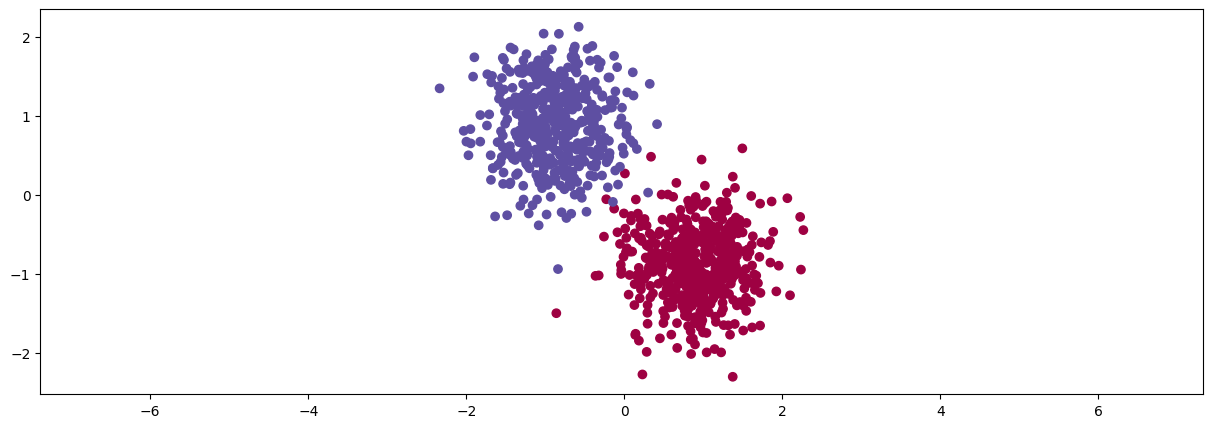

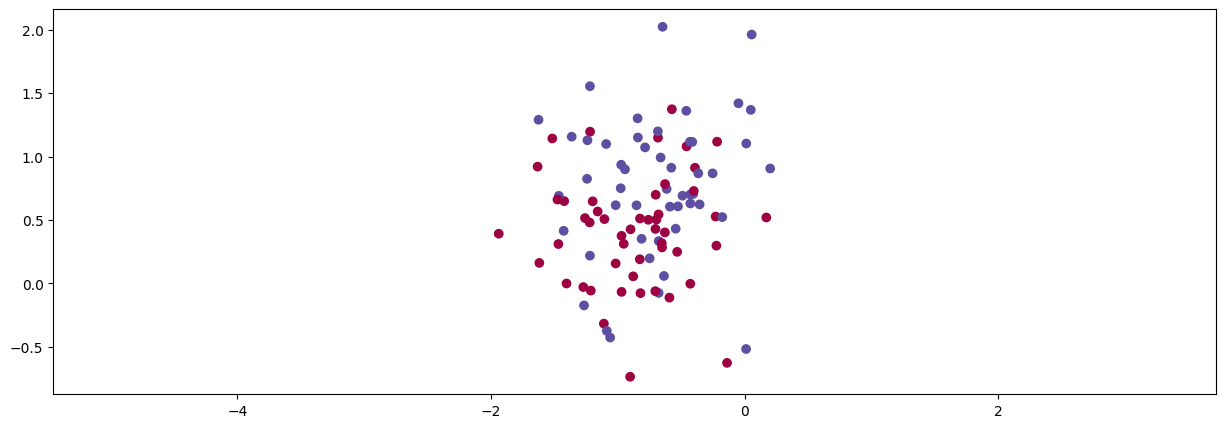

In [38]:
N = 1000

X, y = make_blobs(n_samples=N, n_features=50, centers=2,
                  cluster_std=3.0, random_state=seed)
y[y != 1] = -1

# Scale data and plot
X = scaler.fit_transform(X)

plt.scatter(X[:,0], X[:,1], c=y, cmap=my_cmap)
plt.axis('equal')
plt.show()

N_new=100
X_new, y_new = make_blobs(n_samples=N_new, n_features=50, centers=2,
                  cluster_std=3.0, random_state=seed+1)

# Transform new data
X_new = scaler.transform(X_new)

plt.scatter(X_new[:,0], X_new[:,1], c=y_new, cmap=my_cmap)
plt.axis('equal')
plt.show()

In [39]:
from itertools import product

def plot_diffusion_embeddings(X_train, c_train, X_new, c_new, param_grid,
                                                 n_rows_per_fig=3, figsize=(15, 10)):
    """
    Visualize Diffusion Maps embeddings for different parameter combinations,
    splitting the plots into multiple figures (each with n_rows_per_fig rows) to better display them.

    Parameters:
    - X_train: Training data (numpy array)
    - c_train: Color values/labels for training data
    - X_new: New data to project
    - c_new: Color values/labels for new data
    - param_grid: Dictionary of parameter lists to test (e.g., {'sigma': [...], 'alpha': [...], 'step': [...]})
    - n_rows_per_fig: Number of parameter combinations to show per figure
    - figsize: Figure dimensions for each figure
    """
    param_combos = list(product(*param_grid.values()))
    n_total = len(param_combos)
    
    for i in range(0, n_total, n_rows_per_fig):
        batch = param_combos[i:i+n_rows_per_fig]
        n_rows = len(batch)
        
        _, axs = plt.subplots(n_rows, 2, figsize=figsize)
        if n_rows == 1:
            axs = np.expand_dims(axs, axis=0)
            
        plt.subplots_adjust(hspace=0.5, wspace=0.3)
        
        for row_idx, (sigma, alpha, step) in enumerate(batch):
            dm = DM(sigma=sigma, alpha=alpha, step=step, n_components=2)
            train_emb = dm.fit_transform(X_train)
            new_emb = dm.transform(X_new)
            
            axs[row_idx, 0].scatter(train_emb[:, 0], train_emb[:, 1],
                                    c=c_train, cmap=my_cmap)
            axs[row_idx, 0].set_title(f"Train\n$\\sigma$={sigma}, $\\alpha$={alpha}, t={step}", fontsize=10)
            
            axs[row_idx, 1].scatter(new_emb[:, 0], new_emb[:, 1],
                                    c=c_new, cmap=my_cmap, marker='X')
            axs[row_idx, 1].set_title(f"New\n$\\sigma$={sigma}, $\\alpha$={alpha}, t={step}", fontsize=10)
        
        plt.show()

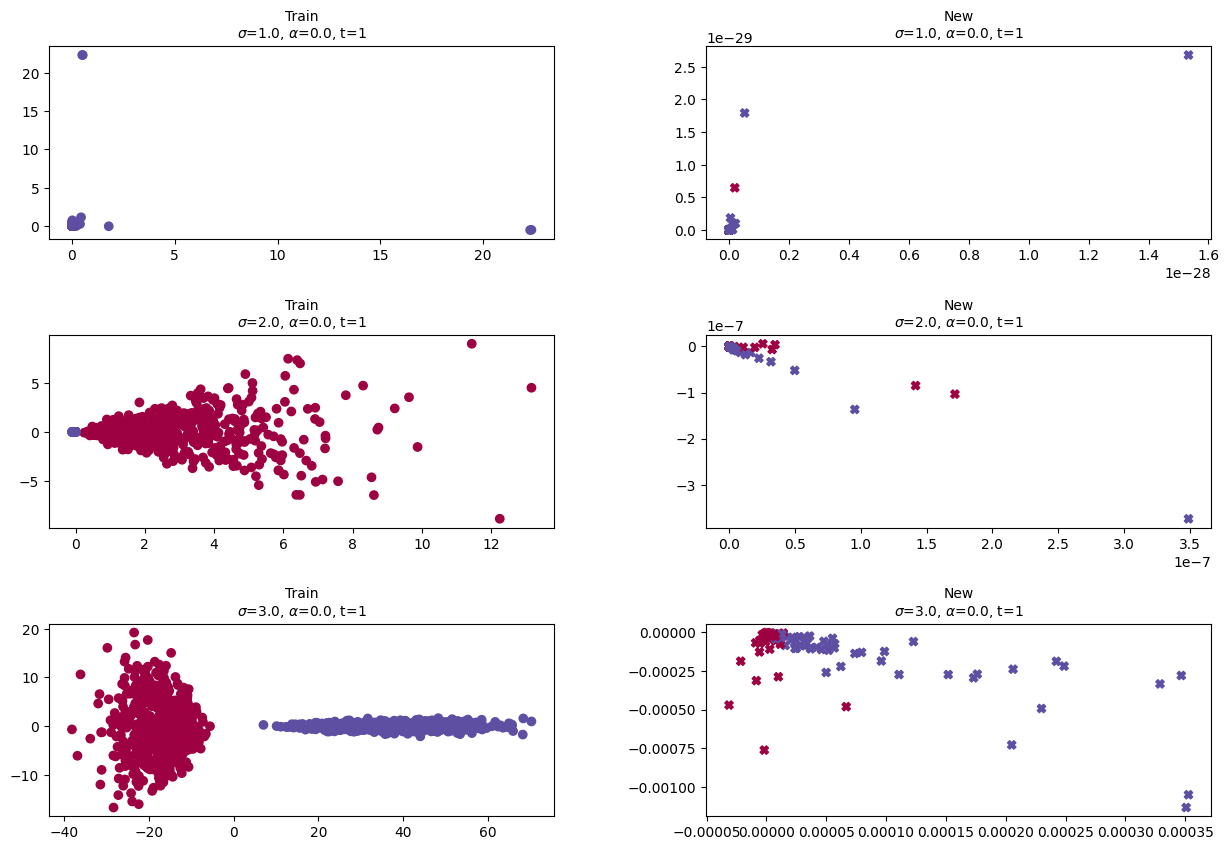

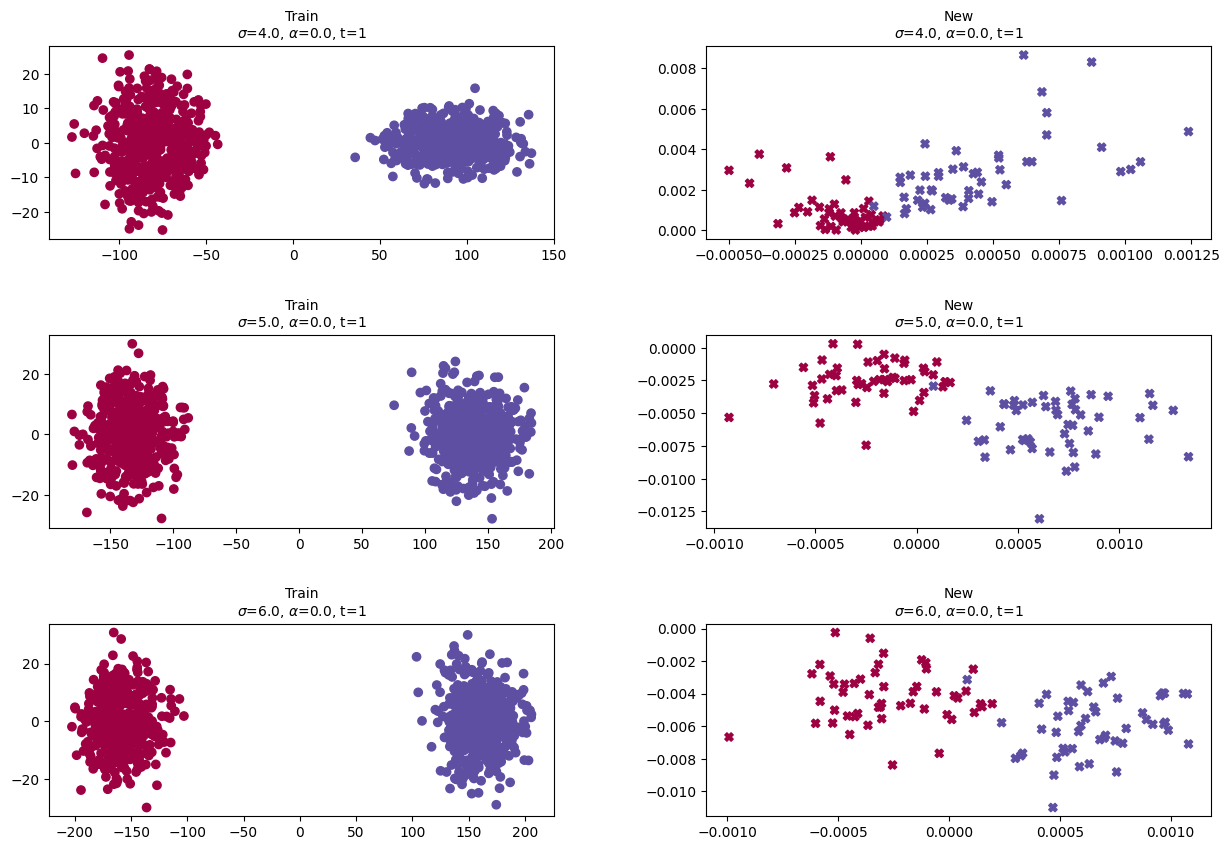

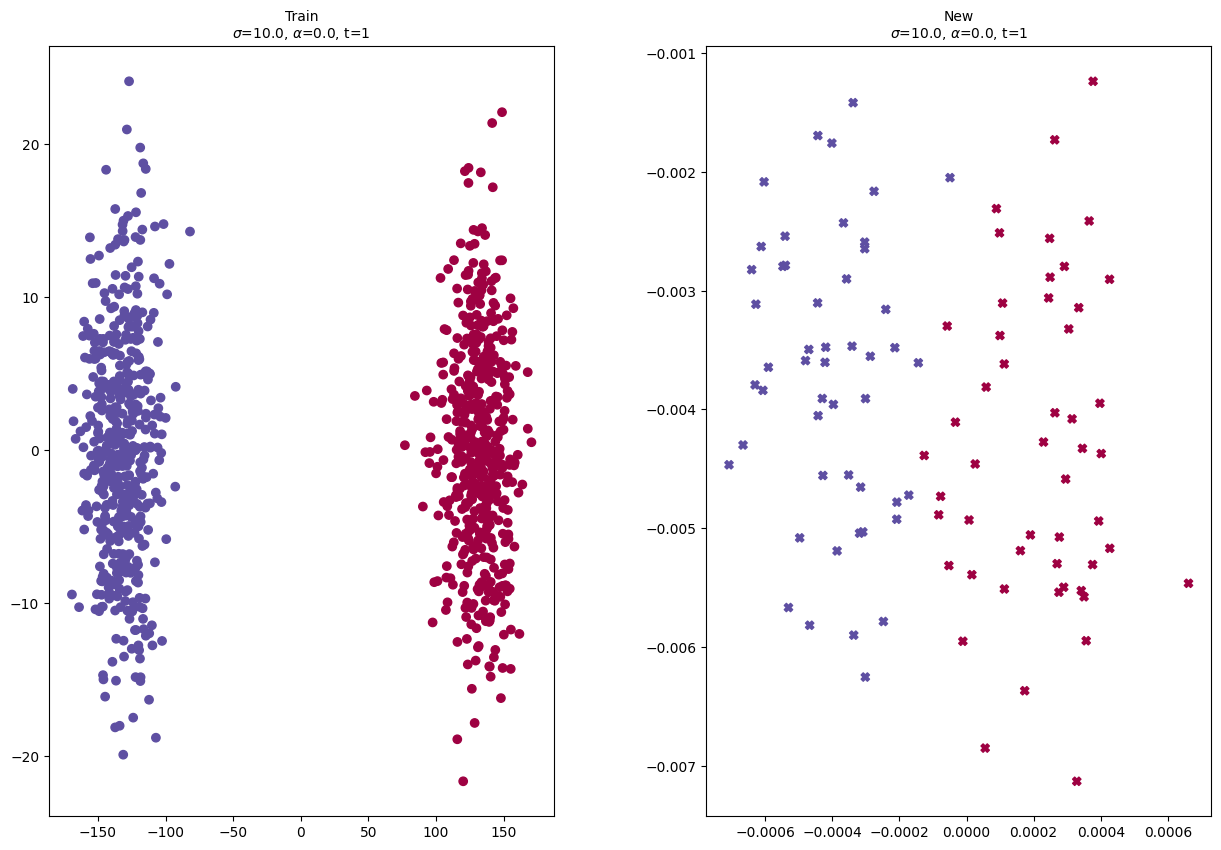

In [40]:
param_grid = {
    'sigma': [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0],
    'alpha': [0.0],
    'step': [1]
}

plot_diffusion_embeddings(X, y, X_new, y_new, param_grid)

## Dataset 2: the swiss roll

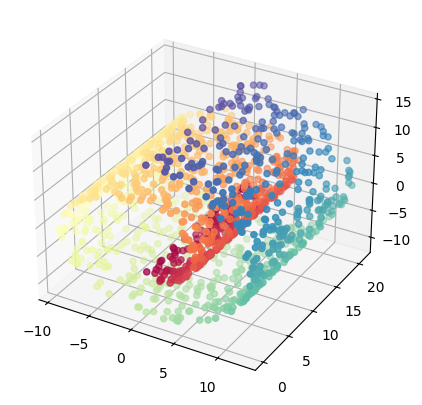

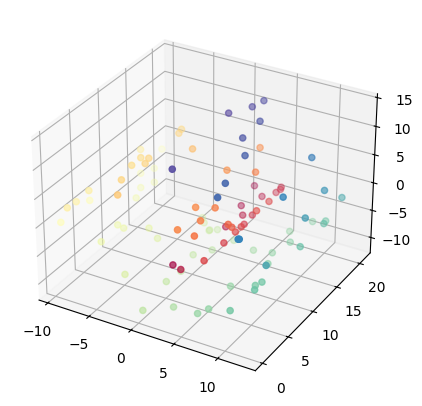

In [10]:
N=1500
X, color = make_swiss_roll(n_samples=N, random_state=seed)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=my_cmap)
plt.show()

N_new=100
X_new, color_new = make_swiss_roll(n_samples=N_new, random_state=seed+1)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_new[:, 0], X_new[:, 1], X_new[:, 2], c=color_new, cmap=my_cmap)
plt.show()


/var/folders/0d/8kqvw6753z1dyht_2pk2mtsc0000gn/T/ipykernel_44398/2186611960.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


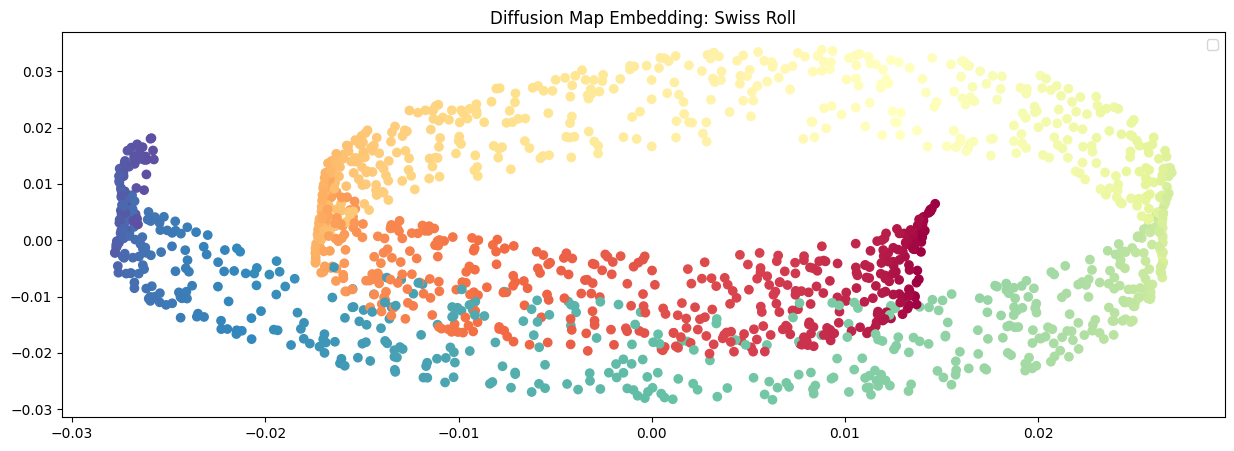

/var/folders/0d/8kqvw6753z1dyht_2pk2mtsc0000gn/T/ipykernel_44398/2186611960.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


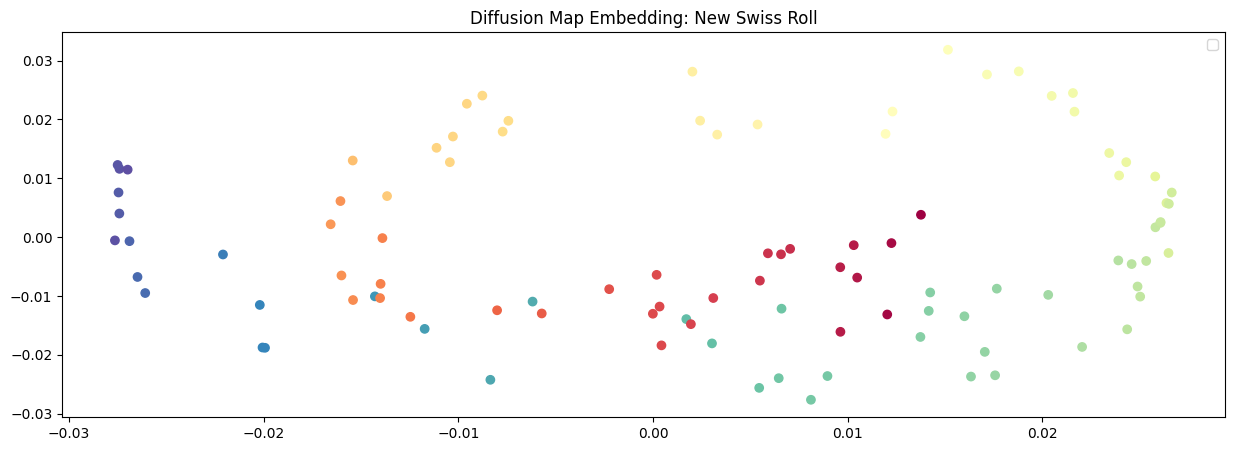

In [11]:
#Solution here

# Set hyperparameters (tuning sigma is critical; here we use sigma=10)
alpha_2 = 0.5
sigma_2 = 10.0
n_components_2 = 2
step_2 = 1

dm_swiss = DM(sigma=sigma_2, n_components=n_components_2, step=step_2, alpha=alpha_2)
X_red_swiss = dm_swiss.fit_transform(X)
X_new_red_swiss = dm_swiss.transform(X_new)

# Plot the embedding
plt.figure()
plt.scatter(X_red_swiss[:,0], X_red_swiss[:,1], c=color, cmap=my_cmap)
plt.title("Diffusion Map Embedding: Swiss Roll")
plt.legend()
plt.show()

# Plot the embedding for the new points
plt.figure()
plt.scatter(X_new_red_swiss[:,0], X_new_red_swiss[:,1], c=color_new, cmap=my_cmap)
plt.title("Diffusion Map Embedding: New Swiss Roll")
plt.legend()
plt.show()


## Dataset 3: the S curve

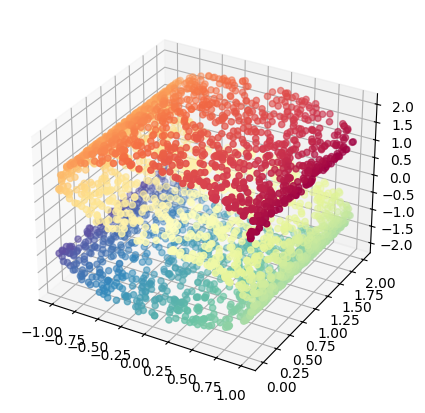

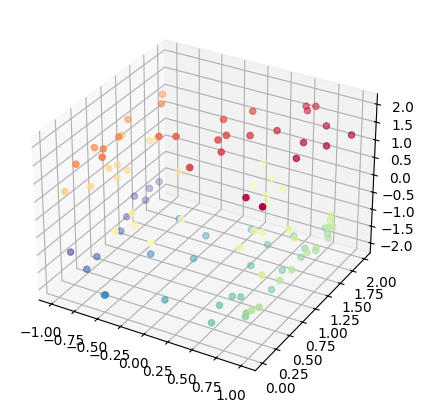

In [12]:
N = 3000
X, color = make_s_curve(N, random_state=seed)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=my_cmap)
plt.show()

N_new = 100
X_new, color_new = make_s_curve(N_new, random_state=seed+1)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_new[:, 0], X_new[:, 1], X_new[:, 2], c=color_new, cmap=my_cmap)
plt.show()

/var/folders/0d/8kqvw6753z1dyht_2pk2mtsc0000gn/T/ipykernel_44398/2008077685.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


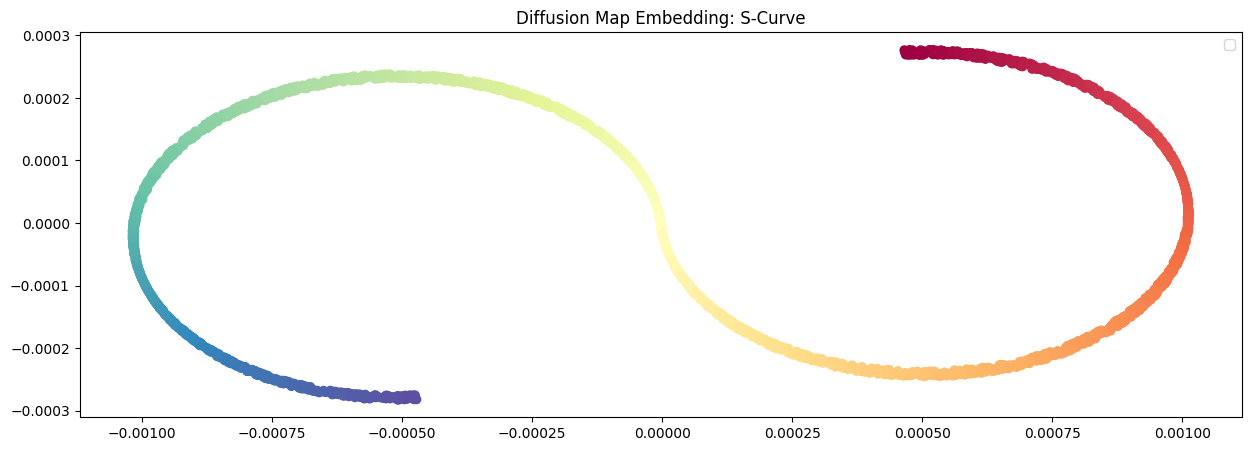

/var/folders/0d/8kqvw6753z1dyht_2pk2mtsc0000gn/T/ipykernel_44398/2008077685.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


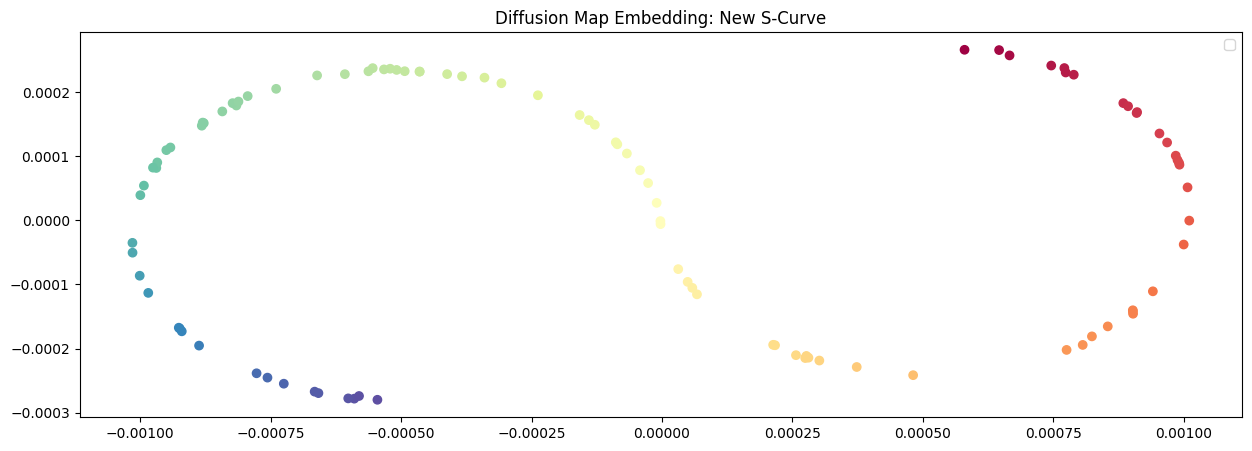

In [13]:
#Solution here

# For the S-curve we use similar hyperparameters to the swiss roll
alpha_3 = 0.5
sigma_3 = 10.0
n_components_3 = 2
step_3 = 1

dm_scurve = DM(sigma=sigma_3, n_components=n_components_3, step=step_3, alpha=alpha_3)
X_red_scurve = dm_scurve.fit_transform(X)
X_new_red_scurve = dm_scurve.transform(X_new)

# Plot the embedding
plt.figure()
plt.scatter(X_red_scurve[:,0], X_red_scurve[:,1], c=color, cmap=my_cmap)
plt.title("Diffusion Map Embedding: S-Curve")
plt.legend()
plt.show()

# Plot the embedding for the new points
plt.figure()
plt.scatter(X_new_red_scurve[:,0], X_new_red_scurve[:,1], c=color_new, cmap=my_cmap)
plt.title("Diffusion Map Embedding: New S-Curve")
plt.legend()
plt.show()

<div class="qst">

1. Do you consider that the embedding obtained is good for the previous datasets? Is it the expected one? Why?
    
    
2. How sensible is the method to its hyper-parameters? Specify the best values that you have found and the technique employed for it.
    * Check how much influence has the sample density (you can vary N for each dataset).
    * Check what happens if the number of steps `steps` grows.
   
    
3. In your opinion, which is the main advantage and disadvantage of this method?
    
</div>

**Answer**: